## Add available geomorphological information to the **Final Dataset** ##

In [1]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [4]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv', encoding=enc)
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [5]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2022-01-01,αττικης,αγιας βαρβαρας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,2.4,26759.0,10925.9,44.75555,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,10.76,11.37,10.15,10.832500,5.546842,14.117500,7.650000,15.820000,4.696667,26.607647,14.388667,0.130592,0.130592,0.130592,43,0,0
1,23.82642,38.00806,2022-01-01,αττικης,αγιας παρασκευης,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,7.9,62157.0,7557.5,44.85879,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,11.06,13.27,8.85,8.846364,5.212353,14.542000,6.439091,14.580909,4.227143,24.649000,13.442000,0.062748,0.062748,0.062748,7,0,0
2,23.73031,37.93357,2022-01-01,αττικης,αγιου δημητριου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,5.0,71747.0,14402.8,44.74465,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,10.30,10.97,9.63,10.853636,5.813750,15.132000,8.207500,16.894444,5.475333,26.081000,14.275556,0.160617,0.160617,0.160617,38,0,0
3,23.71341,38.04721,2022-01-01,αττικης,αγιων αναργυρων καματερου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,9.2,61427.0,6833.8,44.83209,0.142320,0.208147,-0.050086,-0.208147,0.085710,0.073944,-0.025552,-0.073944,0.028794,0.024213,0.017305,0.024213,10.03,10.83,9.23,10.662500,4.884118,14.885000,6.054000,15.932222,3.523333,26.894706,13.191176,0.170459,0.170459,0.170459,39,0,0
4,23.34009,37.69503,2022-01-01,αττικης,αγκιστριου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,13.4,1107.0,85.2,44.33593,0.383779,0.179606,-0.257308,-0.179606,0.390906,0.204594,-0.264321,-0.204594,0.029943,0.073466,0.046621,0.073466,14.08,15.63,12.53,11.994211,8.438571,13.679231,9.048667,13.063846,8.526923,19.013000,14.242000,0.000000,0.000000,0.000000,1,0,0


In [6]:
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.46396,37.33108,1426.812825,9526.118856,24,50.314461,387.046710,184.247277,0.0,1.000000
1,23.47454,37.73169,1901.598942,5182.958716,12,258.873851,229.509683,196.039884,0.0,1.812562
2,23.49722,37.71372,2205.171204,3731.540147,25,207.589234,289.724049,176.975937,0.0,1.891786
3,23.51990,37.74966,1606.369095,2361.867631,31,254.408817,128.656796,180.511498,0.0,1.306699
4,23.72137,37.99391,6716.989270,1493.626330,2,212.539863,68.539566,184.962678,0.0,1.629068


In [7]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)

In [8]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 3.9952337143388092


In [9]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

In [10]:
for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [11]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')

In [12]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.65697,37.99220,2022-01-01,αττικης,αγιας βαρβαρας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,2.4,26759.0,10925.9,44.75555,0.088984,0.007463,-0.126761,-0.007463,0.038651,0.096033,-0.009908,-0.096033,0.000000,0.000000,0.000000,0.000000,10.76,11.37,10.15,10.832500,5.546842,14.117500,7.650000,15.820000,4.696667,26.607647,14.388667,0.130592,0.130592,0.130592,43,0,0,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851
1,23.82642,38.00806,2022-01-01,αττικης,αγιας παρασκευης,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,7.9,62157.0,7557.5,44.85879,0.149062,0.084472,-0.143044,-0.084472,0.160283,0.090071,-0.149035,-0.090071,0.014999,0.017747,0.009902,0.017747,11.06,13.27,8.85,8.846364,5.212353,14.542000,6.439091,14.580909,4.227143,24.649000,13.442000,0.062748,0.062748,0.062748,7,0,0,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984
2,23.73031,37.93357,2022-01-01,αττικης,αγιου δημητριου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,5.0,71747.0,14402.8,44.74465,-0.022605,0.149367,0.122705,-0.149367,-0.025037,0.099860,0.096549,-0.099860,0.048369,0.075880,0.093470,0.075880,10.30,10.97,9.63,10.853636,5.813750,15.132000,8.207500,16.894444,5.475333,26.081000,14.275556,0.160617,0.160617,0.160617,38,0,0,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627
3,23.71341,38.04721,2022-01-01,αττικης,αγιων αναργυρων καματερου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,9.2,61427.0,6833.8,44.83209,0.142320,0.208147,-0.050086,-0.208147,0.085710,0.073944,-0.025552,-0.073944,0.028794,0.024213,0.017305,0.024213,10.03,10.83,9.23,10.662500,4.884118,14.885000,6.054000,15.932222,3.523333,26.894706,13.191176,0.170459,0.170459,0.170459,39,0,0,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759
4,23.34009,37.69503,2022-01-01,αττικης,αγκιστριου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,13.4,1107.0,85.2,44.33593,0.383779,0.179606,-0.257308,-0.179606,0.390906,0.204594,-0.264321,-0.204594,0.029943,0.073466,0.046621,0.073466,14.08,15.63,12.53,11.994211,8.438571,13.679231,9.048667,13.063846,8.526923,19.013000,14.242000,0.000000,0.000000,0.000000,1,0,0,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489


<AxesSubplot:>

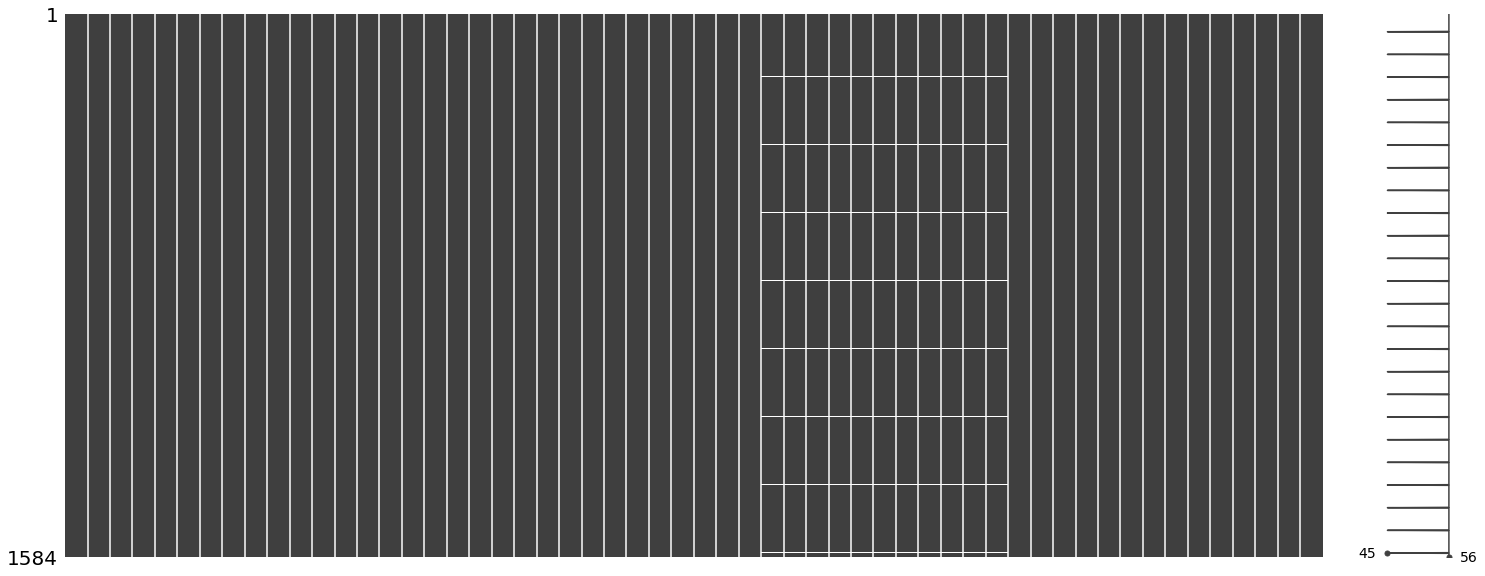

In [13]:
missingno.matrix(dataset)

In [14]:
cols = dataset.columns

In [15]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'mosq_previous', 'case', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m'],
      dtype='object')

In [16]:
len(cols)

56

In [17]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [18]:
len(rearranged)

56

In [19]:
dataset = dataset[rearranged]

In [20]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv", encoding = enc, index = False)